# Taller: Modelos de Clasificación - Predicción de Envíos en E-Commerce
 
En este notebook encontrarán la estructura general para desarrollar el modelo predictivo de retrasos en los envíos. Sigan las instrucciones de cada sección y completen el código correspondiente.

In [3]:
# Paso 0: Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TIP: Asegúrense de importar aquí los tres clasificadores de scikit-learn que elijan probar,

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# junto con las métricas de evaluación (accuracy_score, confusion_matrix, etc.)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## 1. Carga de Datos y Análisis Exploratorio Inicial

Los datos para realizar el ejercicio se encuentran aqui: [E-Commerce Shipping Data](https://www.kaggle.com/datasets/prachi13/customer-analytics)

In [ ]:
# Paso 1: Usa pandas para cargar el dataset descargado de Kaggle

df = pd.read_csv("Train.csv")

# TIP: Exploren las primeras filas con .head(), verifiquen los tipos de datos con .info()
# y revisen si existen valores nulos antes de avanzar.

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.1 MB


## 2. Preprocesamiento de Datos e Ingeniería de Características
En esta sección deben transformar las variables categóricas en formatos numéricos aptos para los modelos.

In [19]:
#Paso 2: Identificación y transformación de variables categóricas

df_model = df.copy()

# TIP 1 (Encoding Ordinal): Analicen la columna 'Product_importance'. ¿Tiene un orden lógico?
# Apliquen una estrategia que conserve esa jerarquía (ej. low=1, medium=2, high=3).

print("\nProduct_importance:")
print(df["Product_importance"].value_counts())

# TIP 2 (One-Hot Encoding): Analicen las columnas 'Mode_of_Shipment' y 'Warehouse_block'.
# Al no tener un orden lógico, utilicen One-Hot Encoding (pd.get_dummies o OneHotEncoder).

print("\nMode_of_Shipment:")
print(df["Mode_of_Shipment"].value_counts())

print("Warehouse_block:")
print(df["Warehouse_block"].value_counts())


importance_mapping = {
    "low": 1,
    "medium": 2,
    "high": 3
}

df_model["Product_importance"] = df_model["Product_importance"].map(
    importance_mapping
)

df_model = pd.get_dummies(
    df_model,
    columns=["Mode_of_Shipment", "Warehouse_block"],
    drop_first=True,
    dtype=int
)


df_model["Product_importance"].value_counts()

df_model.head()



Product_importance:
Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64

Mode_of_Shipment:
Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64
Warehouse_block:
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F
0,1,4,2,177,3,1,F,44,1233,1,0,0,0,0,1,0
1,2,4,5,216,2,1,M,59,3088,1,0,0,0,0,0,1
2,3,2,2,183,4,1,M,48,3374,1,0,0,0,0,0,0
3,4,3,3,176,4,2,M,10,1177,1,0,0,1,0,0,0
4,5,2,2,184,3,2,F,46,2484,1,0,0,0,1,0,0


In [18]:
# TIP 3: Recuerden definir claramente su matriz de características (X) y el vector objetivo (y).
# El target para este problema es la columna 'Reached.on.Time_Y.N'.

X = df_model.drop(
    ["ID", "Gender", "Reached.on.Time_Y.N"],
    axis=1
)

y = df_model["Reached.on.Time_Y.N"]

## 3. División del Dataset
Separación de los datos en conjuntos de entrenamiento y prueba.

In [21]:
# Paso 3: Train/Test Split
# TIP: Utilicen train_test_split de sklearn. Configuren un test_size adecuado (ej. 15% o 20%)
# y un random_state fijo para que sus resultados sean replicables.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8799, 13)
X_test: (2200, 13)
y_train: (8799,)
y_test: (2200,)


## 4. Entrenamiento de Modelos
 
Deben seleccionar, entrenar y evaluar tres algoritmos de clasificación distintos (por ejemplo: Regresión Logística, Árboles de Decisión, Random Forest, KNN, etc.).

In [32]:
## Paso 4: Entrenamiento y evaluación de modelos

# Modelo 1: Instanciar, entrenar con datos de train y predecir con datos de test. 
# Regresión logística

modelo_logistico = LogisticRegression(solver="liblinear", max_iter=2000, random_state=42)
modelo_logistico.fit(X_train, y_train)
y_pred_logistico = modelo_logistico.predict(X_test)

# Modelo 2: Instanciar, entrenar con datos de train y predecir con datos de test
#Arboles de decisión

modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_arbol.fit(X_train, y_train)
y_pred_arbol = modelo_arbol.predict(X_test)

# Modelo 3: Instanciar, entrenar con datos de train y predecir con datos de test
#Random Forest

modelo_rf = RandomForestClassifier( n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

## 5. Evaluación y Comparación de Resultados
Generen las métricas y las gráficas solicitadas para contrastar el rendimiento de los tres modelos.

In [33]:
# Paso 5: Cálculo de métricas para cada modelo por medio de accuracy_score, confusion_matrix, classification_report, etc.
# TIP: Almacenen los resultados de Accuracy en un diccionario o DataFrame para facilitar la graficación.

accuracy_logistico = accuracy_score(y_test, y_pred_logistico)
accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Regresión Logística:", accuracy_logistico)
print("Accuracy Árbol de Decisión:", accuracy_arbol)
print("Accuracy Random Forest:", accuracy_rf)

Accuracy Regresión Logística: 0.6422727272727272
Accuracy Árbol de Decisión: 0.6336363636363637
Accuracy Random Forest: 0.6622727272727272


In [34]:
print("=== REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, y_pred_logistico))

print("=== ÁRBOL DE DECISIÓN ===")
print(classification_report(y_test, y_pred_arbol))

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

=== REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

           0       0.55      0.59      0.57       887
           1       0.71      0.68      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.65      0.64      0.64      2200

=== ÁRBOL DE DECISIÓN ===
              precision    recall  f1-score   support

           0       0.55      0.53      0.54       887
           1       0.69      0.71      0.70      1313

    accuracy                           0.63      2200
   macro avg       0.62      0.62      0.62      2200
weighted avg       0.63      0.63      0.63      2200

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.56      0.71      0.63       887
           1       0.76      0.63      0.69      1313

    accuracy                           0.66      2200
   macro avg       0.66      0.67      0.66      220

In [ ]:
# Paso 6: Gráfica comparativa de Accuracy
# TIP: Utilicen un gráfico de barras (sns.barplot o plt.bar) donde el eje X sean los modelos
# y el eje Y sea el valor de Accuracy obtenido.

resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Árbol de Decisión",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistico,
        accuracy_arbol,
        accuracy_rf
    ]
})

resultados

,Modelo,Accuracy
0,Regresión Logística,0.642273
1,Árbol de Decisión,0.633636
2,Random Forest,0.662273


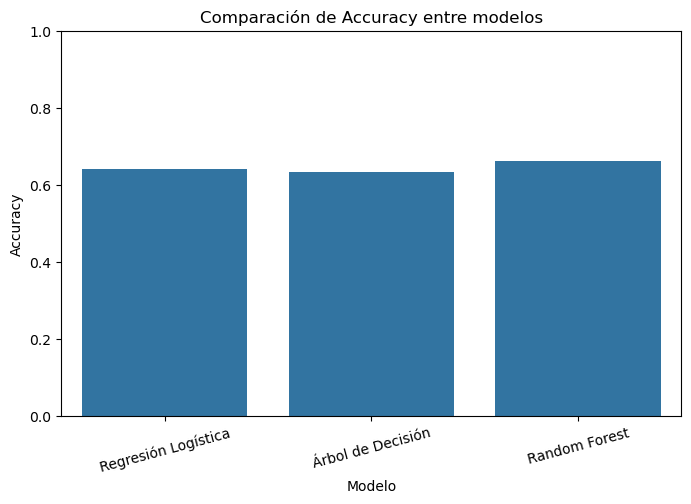

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=resultados,
    x="Modelo",
    y="Accuracy"
)

plt.title("Comparación de Accuracy entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)

plt.show()

In [10]:
# Paso 7: Matrices de Confusión
# TIP: Generen y visualicen la matriz de confusión para cada uno de los tres modelos utilizando sns.heatmap.
# Esto les permitirá analizar visualmente los falsos positivos y falsos negativos de cada algoritmo.

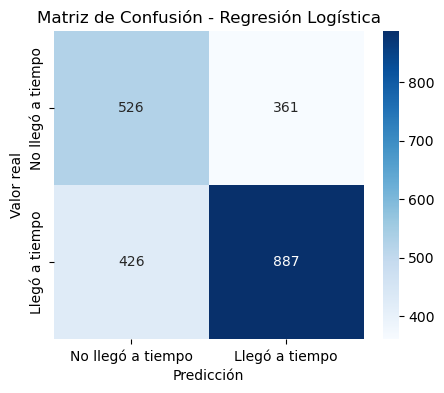

In [41]:
# Matriz de confusión - Regresión Logística

cm_logistico = confusion_matrix(y_test, y_pred_logistico)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_logistico,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No llegó a tiempo", "Llegó a tiempo"],
    yticklabels=["No llegó a tiempo", "Llegó a tiempo"]
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

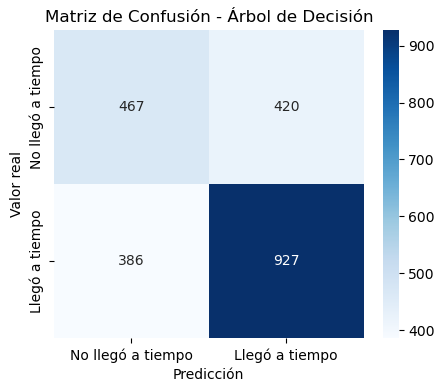

In [42]:
#Mátriz de confusión - Árbol de decisión

cm_arbol = confusion_matrix(y_test, y_pred_arbol)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_arbol,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No llegó a tiempo", "Llegó a tiempo"],
    yticklabels=["No llegó a tiempo", "Llegó a tiempo"]
)

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

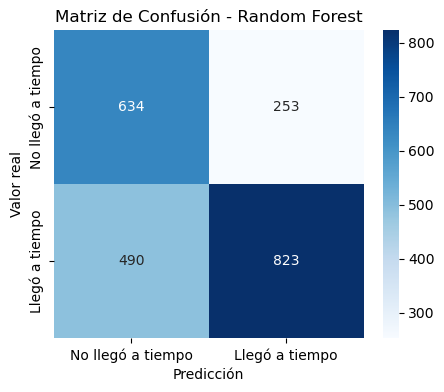

In [43]:
# Mátriz de confusión - Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No llegó a tiempo", "Llegó a tiempo"],
    yticklabels=["No llegó a tiempo", "Llegó a tiempo"]
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()